In [1]:
import sys
print(sys.executable)

/Users/jiya/Desktop/image_classification/venv/bin/python


In [2]:
import cv2
print(cv2.__version__)

4.13.0


In [3]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [4]:
img=cv2.imread('./testimage/sharpova1.jpg')

In [5]:
img.shape

(1200, 1920, 3)

In [6]:
print(img)


[[[207 187 162]
  [206 186 161]
  [205 185 160]
  ...
  [212 198 176]
  [211 197 175]
  [212 198 176]]

 [[208 188 163]
  [207 187 162]
  [207 187 162]
  ...
  [211 197 175]
  [211 197 175]
  [212 198 176]]

 [[208 188 163]
  [208 188 163]
  [207 187 162]
  ...
  [210 196 174]
  [211 197 175]
  [211 197 175]]

 ...

 [[117  83  47]
  [119  85  49]
  [120  86  50]
  ...
  [172 185 193]
  [188 201 209]
  [199 212 220]]

 [[117  83  47]
  [117  83  47]
  [117  83  47]
  ...
  [191 204 212]
  [207 220 228]
  [219 232 240]]

 [[116  82  46]
  [115  81  45]
  [114  80  44]
  ...
  [211 224 232]
  [221 234 242]
  [227 240 248]]]


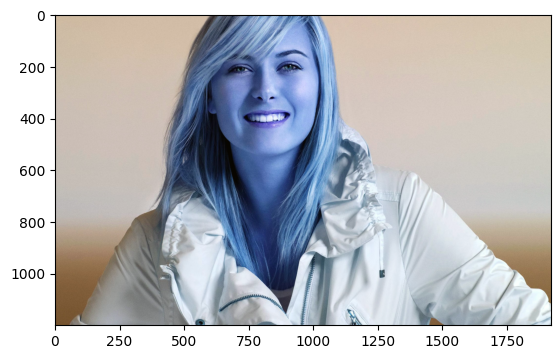

In [7]:
plt.imshow(img)

In [8]:
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray.shape

(1200, 1920)

In [9]:
gray

array([[182, 181, 180, ..., 193, 192, 193],
       [183, 182, 182, ..., 192, 192, 193],
       [183, 183, 182, ..., 191, 192, 192],
       ...,
       [ 76,  78,  79, ..., 186, 202, 213],
       [ 76,  76,  76, ..., 205, 221, 233],
       [ 75,  74,  73, ..., 225, 235, 241]],
      shape=(1200, 1920), dtype=uint8)

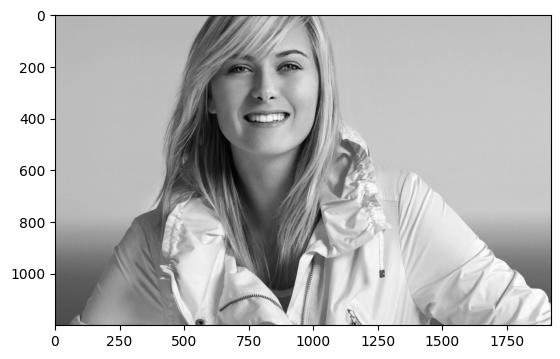

In [10]:
plt.imshow(gray,cmap='gray')

In [11]:
eye_cascade=cv2.CascadeClassifier('./opencv/haarcascade/haarcascade_eye.xml')
face_cascade=cv2.CascadeClassifier('./opencv/haarcascade/haarcascade_frontalface_default.xml')
faces=face_cascade.detectMultiScale(gray,1.3,5)
faces

array([[570,  31, 487, 487]], dtype=int32)

In [12]:
#to get the rectangle around the face we are drawing the rectangle around the face in red color
(x,y,w,h)=faces[0]
x,y,w,h


(np.int32(570), np.int32(31), np.int32(487), np.int32(487))

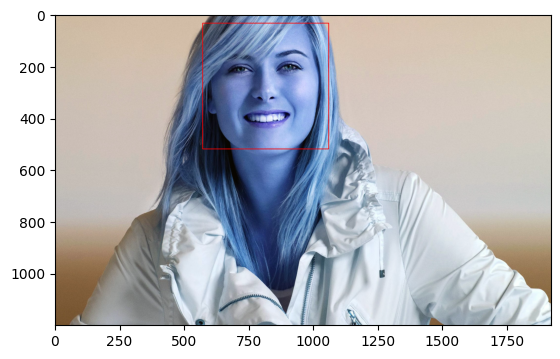

In [13]:
face_img=cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)                      

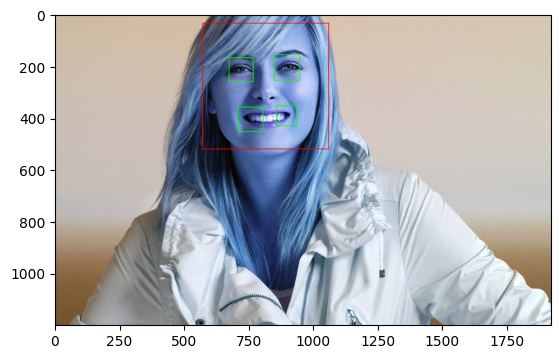

In [14]:
cv2.destroyAllWindows()
for(x,y,w,h)in faces:
    face_img=cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray=gray[y:y+h,x:x+w]
    roi_color=face_img[y:y+h,x:x+w]
    eyes=eye_cascade.detectMultiScale(roi_gray)
    for(ex,ey,ew,eh)in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)


plt.figure()
plt.imshow(face_img,cmap='gray')
plt.show()

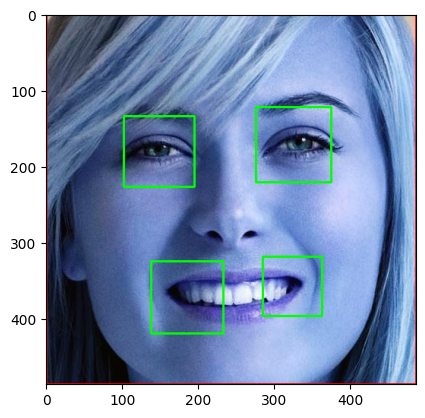

In [15]:
%matplotlib inline
plt.imshow(roi_color,cmap='gray')

In [16]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)

    # FIX: check if image loaded
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray)

        if len(eyes) >= 2:
            return roi_color

    return None

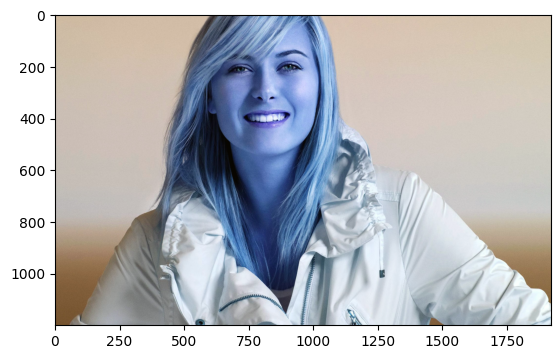

In [17]:
orignal_image=cv2.imread('./testimage/sharpova1.jpg')
plt.imshow(orignal_image)

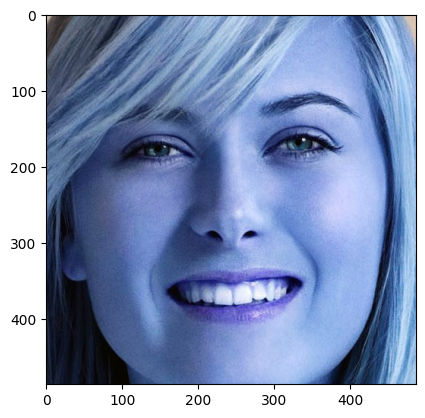

In [18]:
cropped_image=get_cropped_image_if_2_eyes('./testimage/sharpova1.jpg')
plt.imshow(cropped_image)

In [19]:
path_to_data="./dataset/"
path_to_cr_data="./dataset/cropped/"


In [20]:
#this is used to create  a list by which we will collect the data path in a single way we are using os as operating system to connect with the data and files

import os
img_dirs =[]
for entry in os.scandir(path_to_data):#this scandir is used to scan the data 
    if entry.is_dir():
        img_dirs.append(entry.path)
        

In [21]:
img_dirs

['./dataset/maria_sharapova',
 './dataset/virat_kohli',
 './dataset/lionel_messi',
 './dataset/cropped',
 './dataset/serena_williams',
 './dataset/roger_federer']

In [22]:
import shutil 
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)


In [23]:
import os
import cv2

cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1

    celebrity_name = img_dir.split('/')[-1]
    print(celebrity_name)

    celebrity_file_names_dict[celebrity_name] = []

    for entry in os.scandir(img_dir):

        # check only image files
        if entry.is_file() and entry.path.lower().endswith((".png", ".jpg", ".jpeg")):

            roi_color = get_cropped_image_if_2_eyes(entry.path)

            if roi_color is not None:

                cropped_folder = os.path.join(path_to_cr_data, celebrity_name)

                if not os.path.exists(cropped_folder):
                    os.makedirs(cropped_folder)
                    cropped_image_dirs.append(cropped_folder)
                    print("Generating cropped images in folder:", cropped_folder)

                cropped_file_name = celebrity_name + str(count) + ".png"
                cropped_file_path = os.path.join(cropped_folder, cropped_file_name)

                cv2.imwrite(cropped_file_path, roi_color)

                celebrity_file_names_dict[celebrity_name].append(cropped_file_path)

                count += 1

maria_sharapova
Generating cropped images in folder: ./dataset/cropped/maria_sharapova
virat_kohli
Generating cropped images in folder: ./dataset/cropped/virat_kohli
lionel_messi
Generating cropped images in folder: ./dataset/cropped/lionel_messi
cropped
serena_williams
Generating cropped images in folder: ./dataset/cropped/serena_williams
roger_federer
Generating cropped images in folder: ./dataset/cropped/roger_federer


In [24]:
#here we are using a wavelet function w2d and this function extract the importnat features by removing the low frequency informtaion and highlighting edeges and texture


import numpy as np
import pywt
import cv2

def w2d(img, mode='haar', level=1):

    imArray = img

    # convert to grayscale
    imArray = cv2.cvtColor(imArray, cv2.COLOR_RGB2GRAY)

    # convert to float
    imArray = np.float32(imArray)
    imArray /= 255

    # compute wavelet coefficients
    coeffs = pywt.wavedec2(imArray, mode, level=level)

    # remove low-frequency part
    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0

    # reconstruction
    imArray_H = pywt.waverec2(coeffs_H, mode)

    imArray_H *= 255
    imArray_H = np.uint8(imArray_H)

    return imArray_H

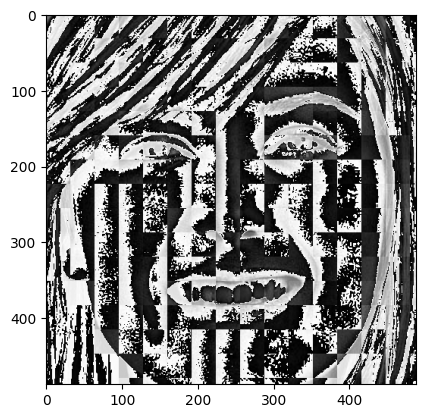

In [25]:
im_har=w2d(cropped_image,'db1',5)
plt.imshow(im_har,cmap='gray')

In [26]:
celebrity_file_names_dict

{'maria_sharapova': ['./dataset/cropped/maria_sharapova/maria_sharapova1.png',
  './dataset/cropped/maria_sharapova/maria_sharapova2.png',
  './dataset/cropped/maria_sharapova/maria_sharapova3.png',
  './dataset/cropped/maria_sharapova/maria_sharapova4.png',
  './dataset/cropped/maria_sharapova/maria_sharapova5.png',
  './dataset/cropped/maria_sharapova/maria_sharapova6.png',
  './dataset/cropped/maria_sharapova/maria_sharapova7.png',
  './dataset/cropped/maria_sharapova/maria_sharapova8.png',
  './dataset/cropped/maria_sharapova/maria_sharapova9.png',
  './dataset/cropped/maria_sharapova/maria_sharapova10.png',
  './dataset/cropped/maria_sharapova/maria_sharapova11.png',
  './dataset/cropped/maria_sharapova/maria_sharapova12.png',
  './dataset/cropped/maria_sharapova/maria_sharapova13.png',
  './dataset/cropped/maria_sharapova/maria_sharapova14.png',
  './dataset/cropped/maria_sharapova/maria_sharapova15.png',
  './dataset/cropped/maria_sharapova/maria_sharapova16.png',
  './dataset/c

In [27]:
class_dict={}
count=0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name]=count
    count=count+1
class_dict    

{'maria_sharapova': 0,
 'virat_kohli': 1,
 'lionel_messi': 2,
 'cropped': 3,
 'serena_williams': 4,
 'roger_federer': 5}

In [28]:
X=[]
y=[]

for celebrity_name,training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        #firstly we will read all the images 
        img=cv2.imread(training_image)
        if img is None:
            continue
        #now we will scaled it to reduce their size to the same size
        scalled_raw_img=cv2.resize(img,(32,32))
        img_har=w2d(img,'db1',5)
        scalled_img_har=cv2.resize(img_har,(32,32))
        #now we are arranging the i that way that our wave image or normal image is adjusted verticle toghtehr 
        combined_img=np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name])
        

In [29]:
len(X)

170

In [30]:
X=np.array(X).reshape(len(X),4096).astype(float)
X.shape

(170, 4096)

In [31]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Users/jiya/Desktop/image_classification/venv/bin/python -m pip install --upgrade pip


In [32]:
import sklearn
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=10))
])

pipe.fit(X_train, y_train)

pipe.score(X_test, y_test)

0.7906976744186046

In [38]:
print(classification_report(y_test,pipe.predict(X_test)))#here f1 score evlautae metric that measure the acuuracy from 01 tp 1

              precision    recall  f1-score   support

           0       0.73      0.89      0.80         9
           1       0.69      1.00      0.81        11
           2       1.00      0.70      0.82        10
           4       0.75      0.43      0.55         7
           5       1.00      0.83      0.91         6

    accuracy                           0.79        43
   macro avg       0.83      0.77      0.78        43
weighted avg       0.82      0.79      0.78        43



In [39]:
#grid serach series
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV


In [44]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [50]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto', probability=True),
        'params': {
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }
    },

    'random_forest': {
        'model': RandomForestClassifier(),
        'params': {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },

'logistic_regression': {
    'model': LogisticRegression(solver='lbfgs', max_iter=1000),
    'params': {
        'logisticregression__C': [1,5,10]
    }
}
}

In [51]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf = GridSearchCV(pipe, mp['params'], cv=5, error_score='raise')
    
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_
    
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,svm,0.653846,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.599385,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.677231,{'logisticregression__C': 1}


In [52]:
best_estimators

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('svc',
                  SVC(C=1, gamma='auto', kernel='linear', probability=True))]),
 'random_forest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier',
                  RandomForestClassifier(n_estimators=10))]),
 'logistic_regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression', LogisticRegression(C=1, max_iter=1000))])}

In [54]:
best_estimators['svm'].score(X_test,y_test)

0.8372093023255814

In [56]:
best_estimators['random_forest'].score(X_test,y_test)


0.7441860465116279

In [57]:
best_estimators['logistic_regression'].score(X_test,y_test)


0.8604651162790697

In [61]:
best_clf = best_estimators['svm']

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_clf.predict(X_test))
cm

array([[ 9,  0,  0,  0,  0],
       [ 0, 11,  0,  0,  0],
       [ 0,  2,  8,  0,  0],
       [ 2,  0,  2,  3,  0],
       [ 0,  0,  0,  1,  5]])

Text(95.72222222222221, 0.5, 'Truth')

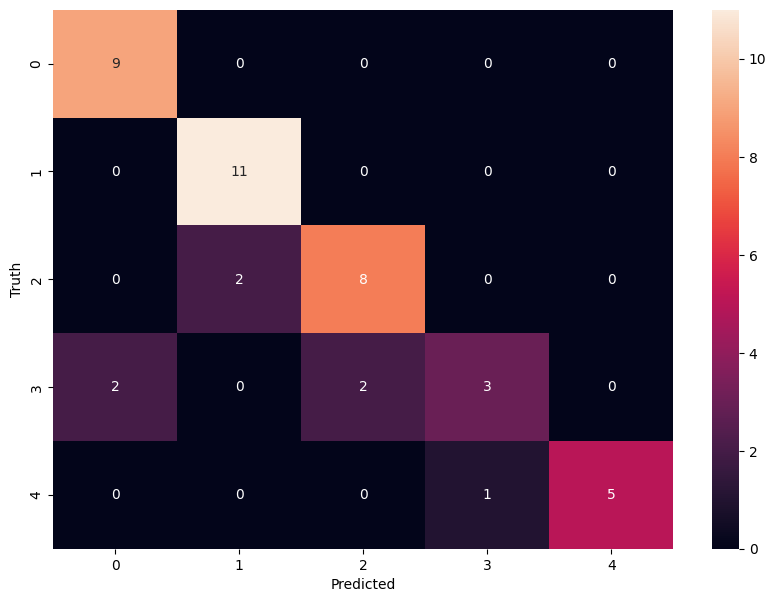

In [62]:
#this is the image of the confusion matrix
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [63]:
class_dict

{'maria_sharapova': 0,
 'virat_kohli': 1,
 'lionel_messi': 2,
 'cropped': 3,
 'serena_williams': 4,
 'roger_federer': 5}

In [64]:
#save the model
!pip install joblib
import joblib
#save the model as a pickle in a file
joblib.dump(best_clf, 'saved_model.pkl')

zsh:1: command not found: pip


['saved_model.pkl']